In [1]:
import torch
import yaml
from torchvision.transforms.functional import adjust_sharpness,adjust_contrast
from Dataset import Boot_Segmentation_Dataset
from torch.utils.data import DataLoader,Dataset
from matplotlib import pyplot as plt
from Model import Unet
from torch import nn
import numpy as np

In [2]:
option_path=fr'/home/artemybombastic/MyGit/KD_Summer_Work/config.yml'
device='cuda' if torch.cuda.is_available() else 'cpu'
device='cpu'
print(device)
with open(option_path,'r') as file_option:
    option=yaml.safe_load(file_option)



cpu


In [3]:
eval_dataset=Boot_Segmentation_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData/low_boots/',option['Segmentation']['label_path'],)
eval_dataloader=DataLoader(dataset=eval_dataset,batch_size=2,drop_last=False,shuffle=True)

In [4]:
for batch in eval_dataloader:
  bt=batch
  break

In [5]:
model=Unet(3,64).to(device)
try:
    weights_dict=torch.load(f'/home/artemybombastic/MyGit/KD_Data/SegmData/unet_model_{device}.pth',weights_only=True)
    model.load_state_dict(weights_dict)
    print('Найдены веса')
except:
    print('Весов нет, инициализируем новые')

Найдены веса


In [6]:
new_batch=adjust_sharpness(adjust_contrast(batch['img'],2),2)
pred=model(batch['img'].to(device))

In [7]:
def cut_boot_from_photo(img,mask,tresh=0.005):
  sig=nn.Sigmoid()
  real_mask = (sig(mask)>sig(mask).mean().item()).float()
  new_img=real_mask*img
  white=np.ones((1024,512,3),np.float32)#фон
  new_img[new_img==0.0]=1.0
  #return new_img.permute(1,2,0)
  return new_img,real_mask

In [8]:
def cut_boot_from_photo(img,mask,tresh=0.005):
  sig=nn.Sigmoid()
  real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2)
  new_img=real_mask*img
  white=np.ones((1024,512,3),np.float32)#фон
  new_img[new_img==0.0]=1.0
  #return new_img.permute(1,2,0)
  return new_img,real_mask

In [9]:
a=cut_boot_from_photo(bt['img'][1],pred[1])

In [10]:
a[1].shape

torch.Size([1, 1024, 512])

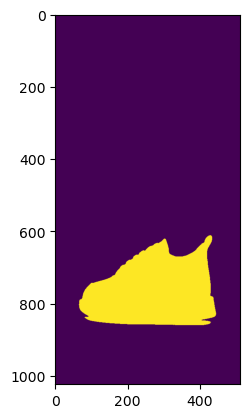

In [11]:
plt.imshow(a[1].permute(1,2,0))

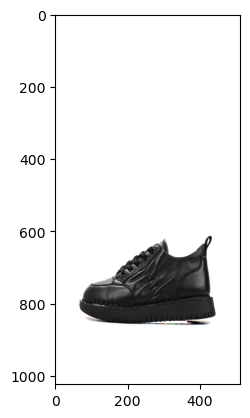

In [12]:
plt.imshow(a[0].permute(1,2,0))

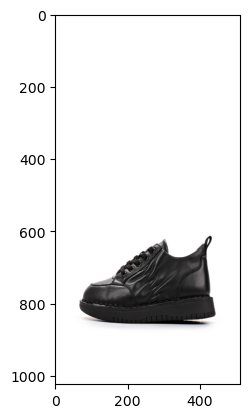

In [13]:
plt.imshow(bt['img'][1].permute(1,2,0).detach())

In [ ]:
Я ДЕЛАЛ ОПРЕДЕЛИТЕЛЬ ТЕНИ НАДО ВСТАВИТЬ В ТОТ НОУТБУК 